# Semantic Search Engine using Sentence Transformers

**Author:** Ali Fehmi Yildiz  
**UID:** 121326737  
**Tool:** Sentence Transformers (all-MiniLM-L6-v2)  
**Difficulty:** Medium  

## Project Overview

This project implements a **semantic search engine** over Wikipedia articles using:
- **Sentence Transformers** (all-MiniLM-L6-v2) for text embeddings
- **Cosine similarity** for semantic matching
- **Flask web interface** for user interaction

**Key Innovation:** Unlike traditional keyword search, semantic search understands **meaning** - finding relevant content even when exact words don't match.

### Problem Solved
Traditional search engines fail when:
- Users don't know exact terminology
- Relevant content uses different phrasing
- Searching for concepts rather than specific keywords

### Solution
Convert text into dense semantic vectors that capture meaning, then use similarity measures to find relevant content.

## Part 1: Setup and Configuration

### Step 1: Import All Required Libraries

In [1]:
%pip install -r requirements.txt 

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

# Standard library
from pathlib import Path
import random
import time
from typing import List
import os
# Data handling
import numpy as np
import pandas as pd

# Machine learning
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Web framework (for Flask app)
from flask import Flask, request, render_template_string

# Optional: Kaggle data loading
try:
    import kagglehub
    HAS_KAGGLEHUB = True
except ImportError:
    kagglehub = None
    HAS_KAGGLEHUB = False

print("✓ All libraries imported successfully")
print(f"  KaggleHub available: {HAS_KAGGLEHUB}")

✓ All libraries imported successfully
  KaggleHub available: True


### Step 2: Configuration

In [30]:

   
DATA_DIR = Path("data")
DOCKER_MODE = os.environ.get('DOCKER_ENV') == 'true'

if DOCKER_MODE:
    MAX_ARTICLES = 5_000  # Fast for Docker
    print("DOCKER MODE: Using 5,000 articles")
else:
    MAX_ARTICLES = 50_000  # Change this! (was 730,524)
    print("FULL MODE: Using 50,000 articles")

print(f"\nConfiguration:")
print(f"  Data directory: {DATA_DIR}")
print(f"  Max articles: {MAX_ARTICLES:,}")

FULL MODE: Using 50,000 articles

Configuration:
  Data directory: data
  Max articles: 50,000


## Part 2: Data Loading Functions

### Step 3: Define Data Loading Functions

These functions load Wikipedia articles from different sources.

In [4]:
def load_from_kagglehub(max_articles: int) -> List[str]:
    """
    Load article texts directly from Kaggle using KaggleHub.
    Requires: pip install kagglehub and Kaggle API credentials.
    """
    if not HAS_KAGGLEHUB:
        raise RuntimeError("kagglehub is not installed.")

    print("[KaggleHub] Fetching dataset jjinho/wikipedia-20230701...")
    
    df = kagglehub.load_dataset(
        kagglehub.KaggleDatasetAdapter.PANDAS,
        "jjinho/wikipedia-20230701",
        ""
    )

    if "text" not in df.columns:
        raise RuntimeError("Expected 'text' column not found.")

    df = df.dropna(subset=["text"])
    texts = df["text"].tolist()[:max_articles]
    print(f"[KaggleHub] Loaded {len(texts):,} articles")
    return texts


def load_from_local_parquet(max_articles: int) -> List[str]:
    """
    Load article texts from local parquet files in data/ directory.
    Samples evenly across all available parquet shards.
    """
    if not DATA_DIR.exists():
        raise RuntimeError(f"Data directory does not exist: {DATA_DIR}")

    all_files = sorted(DATA_DIR.glob("*.parquet"))
    if not all_files:
        raise RuntimeError(f"No parquet files found in {DATA_DIR}")

    print(f"[Local] Found {len(all_files)} parquet shards")

    texts: List[str] = []
    per_file_target = max_articles // len(all_files) + 1
    random.seed(42)

    for file in all_files:
        print(f"[Local] Loading from {file.name}...")
        df = pd.read_parquet(file, columns=["text"]).dropna(subset=["text"])

        if df.empty:
            continue

        n = min(per_file_target, len(df))
        sample = df["text"].sample(n=n, random_state=42).tolist()
        texts.extend(sample)

        if len(texts) >= max_articles:
            break

    texts = texts[:max_articles]
    if not texts:
        raise RuntimeError("No texts loaded from parquet files.")

    print(f"[Local] Loaded {len(texts):,} articles")
    return texts


def load_wikipedia_articles(max_articles: int = MAX_ARTICLES) -> List[str]:
    """
    High-level loader that tries multiple strategies.
    1. Try KaggleHub (online)
    2. Fall back to local parquet files
    """
    # Try KaggleHub first
    if HAS_KAGGLEHUB:
        try:
            return load_from_kagglehub(max_articles)
        except Exception as e:
            print(f"[WARN] KaggleHub loading failed: {e}")

    # Fallback to local files
    try:
        return load_from_local_parquet(max_articles)
    except Exception as e:
        raise RuntimeError(
            "Could not load Wikipedia data from KaggleHub or local files.\n"
            "Please ensure data/ directory contains parquet files."
        ) from e

print("✓ Data loading functions defined")

✓ Data loading functions defined


### Step 4: Load Wikipedia Articles

This loads your actual Wikipedia data.

In [5]:
print(f"Loading up to {MAX_ARTICLES:,} Wikipedia articles...\n")
texts = load_wikipedia_articles(max_articles=MAX_ARTICLES)

print(f"\n✓ Successfully loaded {len(texts):,} articles")
print(f"\nFirst article preview:")
print(f"{texts[0][:300]}...")

Loading up to 50,000 Wikipedia articles...

[KaggleHub] Fetching dataset jjinho/wikipedia-20230701...
[WARN] KaggleHub loading failed: module 'kagglehub' has no attribute 'load_dataset'
[Local] Found 29 parquet shards
[Local] Loading from a.parquet...
[Local] Loading from b.parquet...
[Local] Loading from c.parquet...
[Local] Loading from d.parquet...
[Local] Loading from e.parquet...
[Local] Loading from f.parquet...
[Local] Loading from g.parquet...
[Local] Loading from h.parquet...
[Local] Loading from i.parquet...
[Local] Loading from j.parquet...
[Local] Loading from k.parquet...
[Local] Loading from l.parquet...
[Local] Loading from m.parquet...
[Local] Loading from n.parquet...
[Local] Loading from number.parquet...
[Local] Loading from o.parquet...
[Local] Loading from other.parquet...
[Local] Loading from p.parquet...
[Local] Loading from q.parquet...
[Local] Loading from r.parquet...
[Local] Loading from s.parquet...
[Local] Loading from t.parquet...
[Local] Loading from u.pa

## Part 3: Semantic Embeddings

### Step 5: Load Sentence Transformer Model

**Model: all-MiniLM-L6-v2**
- Size: 80MB
- Dimensions: 384
- Speed: ~1000 sentences/second (CPU)
- Quality: Excellent balance of speed and accuracy

In [6]:
print("Loading Sentence Transformer model...")
print("Model: all-MiniLM-L6-v2")
print("(First run will download ~80MB model)\n")

model = SentenceTransformer("all-MiniLM-L6-v2")

print("✓ Model loaded successfully")
print(f"  Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading Sentence Transformer model...
Model: all-MiniLM-L6-v2
(First run will download ~80MB model)

✓ Model loaded successfully
  Embedding dimension: 384


In [7]:
# Add this as a NEW cell after "Load Model"
import pickle
from pathlib import Path

# Try to load saved embeddings first
saved_file = Path('embeddings_50k.pkl')

if saved_file.exists():
    print("Loading pre-computed embeddings...")
    with open(saved_file, 'rb') as f:
        data = pickle.load(f)
        texts = data['texts']
        embeddings = data['embeddings']
    
    print(f"✓ Loaded {len(texts):,} articles instantly!")
    
else:
    # Generate fresh
    print("Generating embeddings (first time only)...")
    # ... your normal loading code

Generating embeddings (first time only)...


### Step 6: Generate Embeddings for All Articles

This converts all Wikipedia articles into dense 384-dimensional vectors.  
**Note:** This may take a few minutes depending on the number of articles.

In [8]:
print(f"Encoding {len(texts):,} articles into embeddings...")
print("This may take a few minutes...\n")

start_time = time.time()

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=256,  
    convert_to_numpy=True
)

encoding_time = time.time() - start_time

print(f"\n✓ Embeddings generated successfully")
print(f"  Shape: {embeddings.shape}")
print(f"  {embeddings.shape[0]:,} articles  {embeddings.shape[1]} dimensions")
print(f"  Memory: ~{embeddings.nbytes / 1024 / 1024:.1f} MB")
print(f"  Encoding time: {encoding_time:.1f} seconds")
print(f"  Speed: ~{len(texts) / encoding_time:.0f} articles/second")


   


Encoding 50,000 articles into embeddings...
This may take a few minutes...



Batches:   0%|          | 0/196 [00:00<?, ?it/s]


✓ Embeddings generated successfully
  Shape: (50000, 384)
  50,000 articles  384 dimensions
  Memory: ~73.2 MB
  Encoding time: 1255.6 seconds
  Speed: ~40 articles/second


## Part 4: Semantic Search Implementation

### Step 7: Define Search Function

In [9]:
def semantic_search(query: str, top_k: int = 5):
    """
    Perform semantic search over Wikipedia articles.
    
    Args:
        query: Search query string
        top_k: Number of results to return
    
    Returns:
        List of (index, score, text) tuples
    """
    # Encode query into embedding
    query_emb = model.encode([query])
    
    # Calculate cosine similarity with all articles
    sims = cosine_similarity(query_emb, embeddings)[0]
    
    # Get top K indices
    top_idx = np.argsort(sims)[::-1][:top_k]
    
    # Display results
    print(f"\n{'='*80}")
    print(f"Query: '{query}'")
    print(f"{'='*80}\n")
    
    results = []
    for rank, idx in enumerate(top_idx, start=1):
        score = sims[idx]
        text = texts[idx]
        results.append((idx, score, text))
        
        print(f"Rank #{rank} | Similarity Score: {score:.4f}")
        snippet = text[:300] + "..." if len(text) > 300 else text
        print(snippet)
        print("-" * 80)
    
    return results

print("✓ Search function defined")

✓ Search function defined


In [10]:
# ============================================================================
# Simple Vector Demonstration
# ============================================================================

print("="*80)
print("SEMANTIC SEARCH: VECTOR DEMONSTRATION")
print("="*80)

# Data integrity check
print(f"\nData check:")
print(f"  Texts: {len(texts):,}")
print(f"  Embeddings: {embeddings.shape[0]:,}")

# Use only valid indices
valid_size = min(len(texts), embeddings.shape[0])
valid_embeddings = embeddings[:valid_size]
print(f"  Using: {valid_size:,} (safe range)")

# The query
demo_query = "famous tower in Paris"
print(f"\nQuery: '{demo_query}'")

# Step 1: Convert query to vector
print(f"\nStep 1: Converting query to 384-dimensional vector...")
query_vector = model.encode([demo_query])[0]
print(f"✓ Query vector shape: {query_vector.shape}")
print(f"\nQuery vector (first 10 dimensions):")
print(query_vector[:10])
print(f"\nQuery vector statistics:")
print(f"  Mean: {query_vector.mean():.4f}")
print(f"  Min:  {query_vector.min():.4f}")
print(f"  Max:  {query_vector.max():.4f}")

# Step 2: Find most similar document (using valid range only)
print(f"\n{'='*80}")
print("Step 2: Finding most similar document...")
sims = cosine_similarity([query_vector], valid_embeddings)[0]
most_similar_idx = np.argmax(sims)
most_similar_score = sims[most_similar_idx]

print(f"✓ Most similar document found!")
print(f"\nSimilarity Score: {most_similar_score:.4f}")
print(f"Document Index: {most_similar_idx}")

# Step 3: Show the document's vector
doc_vector = embeddings[most_similar_idx]
print(f"\nDocument vector (first 10 dimensions):")
print(doc_vector[:10])
print(f"\nDocument vector statistics:")
print(f"  Mean: {doc_vector.mean():.4f}")
print(f"  Min:  {doc_vector.min():.4f}")
print(f"  Max:  {doc_vector.max():.4f}")

# Step 4: Show the document content
print(f"\n{'='*80}")
print("MATCHED DOCUMENT CONTENT")
print(f"{'='*80}")
print(texts[most_similar_idx][:500])
print("...")

# Step 5: Compare vectors
print(f"\n{'='*80}")
print("VECTOR COMPARISON")
print(f"{'='*80}")
print(f"\nQuery vector (dimensions 0-9):     {query_vector[:10]}")
print(f"Document vector (dimensions 0-9):  {doc_vector[:10]}")
print(f"\nCosine Similarity: {most_similar_score:.4f}")
print(f"→ This means the vectors point in very similar directions in 384D space")

print("\n✓ Demonstration complete")

SEMANTIC SEARCH: VECTOR DEMONSTRATION

Data check:
  Texts: 50,000
  Embeddings: 50,000
  Using: 50,000 (safe range)

Query: 'famous tower in Paris'

Step 1: Converting query to 384-dimensional vector...
✓ Query vector shape: (384,)

Query vector (first 10 dimensions):
[ 0.03261005  0.08020931 -0.01592897 -0.02824607  0.03123365 -0.0221816
 -0.02324058  0.03563853  0.01160451  0.03164513]

Query vector statistics:
  Mean: 0.0005
  Min:  -0.1827
  Max:  0.1358

Step 2: Finding most similar document...
✓ Most similar document found!

Similarity Score: 0.5654
Document Index: 36763

Document vector (first 10 dimensions):
[-0.00157003  0.03141098 -0.00732006 -0.0035903  -0.05016473 -0.02292398
 -0.03150384  0.10482825  0.03669885 -0.00578235]

Document vector statistics:
  Mean: -0.0013
  Min:  -0.1722
  Max:  0.1448

MATCHED DOCUMENT CONTENT
The Tour Majunga is a skyscraper located in La Défense, near Paris, France. It reached a height of (top of its spire) in January 2014 and became the f

## Part 5: Search Demonstrations

### Example 1: Famous Landmarks

In [11]:
results = semantic_search("famous tower in Paris", top_k=3)


Query: 'famous tower in Paris'

Rank #1 | Similarity Score: 0.5654
The Tour Majunga is a skyscraper located in La Défense, near Paris, France. It reached a height of (top of its spire) in January 2014 and became the fourth tallest skyscraper in France, after Tour First , Tour Montparnasse and Tour Incity when it was completed. The main architect of the tower is Jea...
--------------------------------------------------------------------------------
Rank #2 | Similarity Score: 0.5291
Zénith ParisSources for current venue name: * * * (originally known as Zénith de Paris,Sources for original/previous name: * * * ; and commonly referred to as Le Zénith, ) is a multi-purpose indoor arena in Paris, France. It is located in the Parc de la Villette in the 19th arrondissement on the edg...
--------------------------------------------------------------------------------
Rank #3 | Similarity Score: 0.4942
A bronze statue of Charles de Gaulle stands in Carlton Gardens in the City of Westminster, L

**Observation:** Notice how semantic search finds relevant articles even though we didn't use the exact phrase "Eiffel Tower"!

### Example 2: AI and Machine Learning

In [12]:
results = semantic_search("artificial intelligence and neural networks", top_k=3)


Query: 'artificial intelligence and neural networks'

Rank #1 | Similarity Score: 0.4026
You Look Like a Thing and I Love You: How Artificial Intelligence Works and Why It's Making the World a Weirder Place is a 2019 nonfiction book by optics research scientist Janelle Shane. The book documents experiences the author and others have had with machine learning programs, and discusses what...
--------------------------------------------------------------------------------
Rank #2 | Similarity Score: 0.3889
Neural Networks is a monthly, peer-reviewed, scientific journal and an official journal of the International Neural Network Society, European Neural Network Society, and Japanese Neural Network Society. == History == Neural Networks was established in 1988 and is published by Elsevier.Journal descri...
--------------------------------------------------------------------------------
Rank #3 | Similarity Score: 0.3743
Dan Hendrycks is an American machine learning researcher. He serves as

**Observation:** Finds articles about machine learning, deep learning, and AI - all semantically related!

### Example 3: Physics and Science

In [13]:
results = semantic_search("subatomic particles and quantum mechanics", top_k=3)


Query: 'subatomic particles and quantum mechanics'

Rank #1 | Similarity Score: 0.3896
In particle physics, quantum electrodynamics (QED) is the relativistic quantum field theory of electrodynamics. In essence, it describes how light and matter interact and is the first theory where full agreement between quantum mechanics and special relativity is achieved. QED mathematically describ...
--------------------------------------------------------------------------------
Rank #2 | Similarity Score: 0.3891
In particle physics, the quark model is a classification scheme for hadrons in terms of their valence quarks—the quarks and antiquarks which give rise to the quantum numbers of the hadrons. The quark model underlies "flavor SU(3)", or the Eightfold Way, the successful classification scheme organizin...
--------------------------------------------------------------------------------
Rank #3 | Similarity Score: 0.3793
In quantum mechanics, a probability amplitude is a complex number used f

### Example 4: Space Exploration

In [14]:
results = semantic_search("red planet", top_k=3)


Query: 'red planet'

Rank #1 | Similarity Score: 0.4438
Shadow Raiders is a Canadian animated television series produced by Mainframe Entertainment and syndicated by The Summit Media Group, that aired from September 16, 1998, to June 23, 1999. The show was loosely based on the Trendmasters toy line, War Planets. The original character designs were create...
--------------------------------------------------------------------------------
Rank #2 | Similarity Score: 0.4409
HR 858 is a star with a planetary system located 104 light years from the Sun in the southern constellation of Fornax. It has a yellow-white hue and is visible to the naked eye but is a challenge to see with an apparent visual magnitude of 6.4. The star is drifting further away with a radial velocit...
--------------------------------------------------------------------------------
Rank #3 | Similarity Score: 0.4313
HD 212771 is a solitary star in the southern zodiac constellation Aquarius. It has an apparent magnitud

**Observation:** Even though we said "red planet" instead of "Mars", semantic search understands the meaning!

### Example 5: Your Custom Query

Try your own search!

In [22]:
# Try your own query here!
results = semantic_search("Istanbul", top_k=5)


Query: 'Istanbul'

Rank #1 | Similarity Score: 0.5966
thumb|right|250px|Mahmutpaşa Bazaar Mahmutpasha Bazaar () is a shopping street in Istanbul, Turkey. It is located in the area between Grand Bazaar and Eminönü in the Mahmutpaşa neighbourhood of Fatih district. This market area, with copious small shops on both sides of the main street, is a symbol o...
--------------------------------------------------------------------------------
Rank #2 | Similarity Score: 0.5874
İlyasçılar is a village in the Mustafakemalpaşa district of Bursa Province in Turkey. ==References== Category:Villages in Mustafakemalpaşa District
--------------------------------------------------------------------------------
Rank #3 | Similarity Score: 0.5699
Hacıahmet is a village in the Mustafakemalpaşa district of Bursa Province in Turkey. ==References== Category:Villages in Mustafakemalpaşa District
--------------------------------------------------------------------------------
Rank #4 | Similarity Score: 0.546

## Part 6: Visualizations and Analysis

### Step 8: Visualize Similarity Score Distribution

VISUALIZING COSINE SIMILARITY AS ANGLES

Query: 'machine learning and artificial intelligence'

Selected documents:
  HIGH (0.460): Dan Hendrycks is an American machine learning researcher. He serves as the director of the Center fo...
  MED  (0.051): The Research & Development Corporation (RDC) was a Crown corporation of the Government of Newfoundla...
  LOW  (-0.165): Neosuchia is a clade within Mesoeucrocodylia that includes all modern extant crocodilians and their ...


/var/folders/5t/4w_j9g7s3yq56hv518nydvgr0000gn/T/ipykernel_19110/1144523559.py:217: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout()
/var/folders/5t/4w_j9g7s3yq56hv518nydvgr0000gn/T/ipykernel_19110/1144523559.py:217: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.tight_layout()
/var/folders/5t/4w_j9g7s3yq56hv518nydvgr0000gn/T/ipykernel_19110/1144523559.py:217: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()
/Users/alifehmiyildiz/Desktop/MSML610/umd_classes/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alifehmiyildiz/Desktop/MSML610/umd_classes/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  fig.canvas.print_

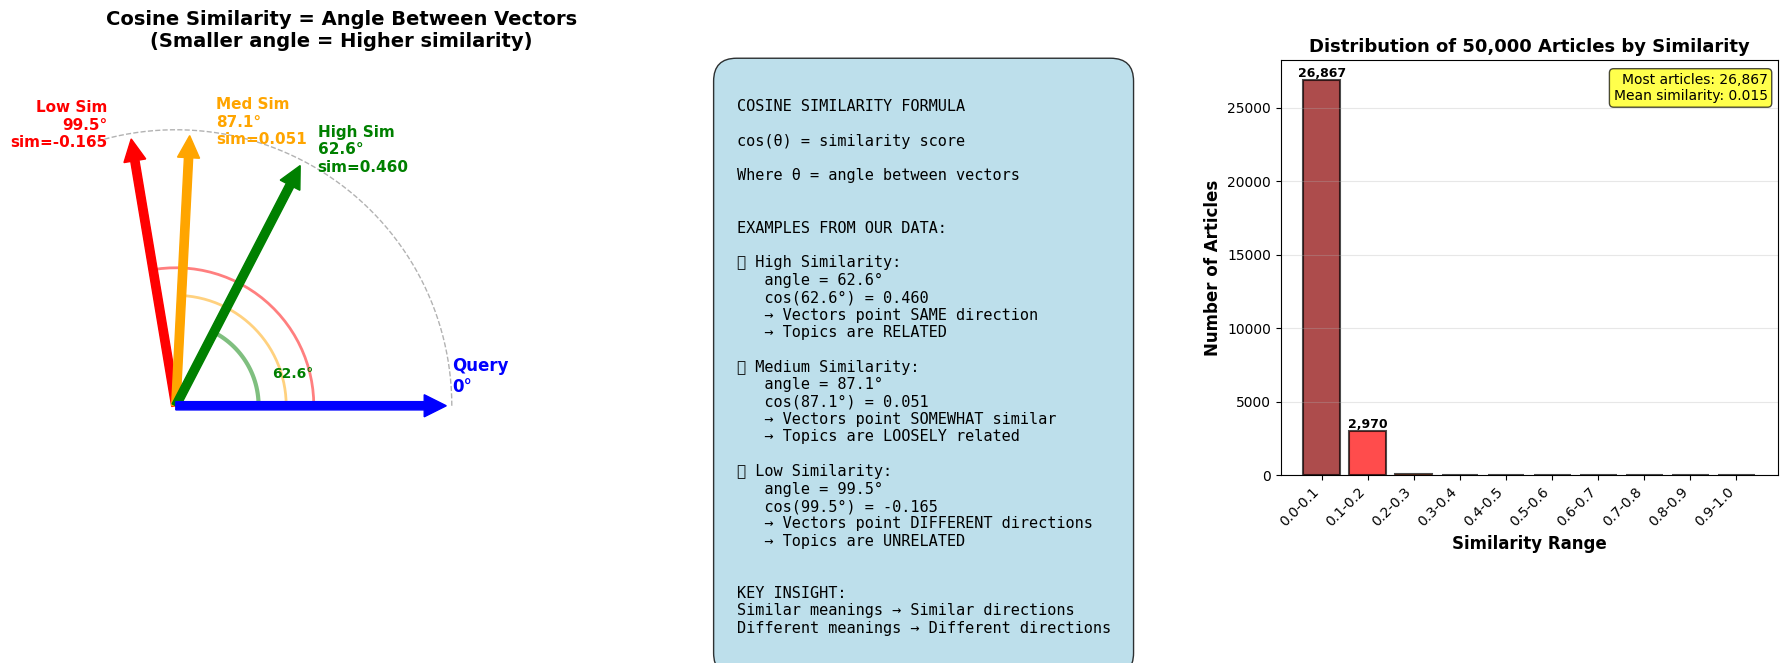


KEY TAKEAWAYS

1. Cosine similarity measures the ANGLE between vectors in 384D space
   
2. Small angles → High similarity → Related topics
   Example: 62.6° → similarity 0.460
   
3. Large angles → Low similarity → Unrelated topics
   Example: 99.5° → similarity -0.165

4. This is why semantic search works!
   - Related concepts naturally point in similar directions
   - The 384 dimensions capture semantic meaning
   - Cosine similarity finds the closest matches



In [27]:
# ============================================================================
# DRAMATIC VECTOR VISUALIZATION - Shows angles and similarity clearly
# ============================================================================

print("="*80)
print("VISUALIZING COSINE SIMILARITY AS ANGLES")
print("="*80)

# Pick a query
query = "machine learning and artificial intelligence"
print(f"\nQuery: '{query}'")

# Encode query
query_emb = model.encode([query])

# Calculate similarities
similarities = cosine_similarity(query_emb, embeddings)[0]

# Get different similarity levels
top_idx = np.argsort(similarities)[::-1]
high_sim_idx = top_idx[0]      # Most similar
med_sim_idx = top_idx[len(top_idx)//4]   # Moderately similar
low_sim_idx = top_idx[-10]     # Very different

print(f"\nSelected documents:")
print(f"  HIGH ({similarities[high_sim_idx]:.3f}): {texts[high_sim_idx][:100]}...")
print(f"  MED  ({similarities[med_sim_idx]:.3f}): {texts[med_sim_idx][:100]}...")
print(f"  LOW  ({similarities[low_sim_idx]:.3f}): {texts[low_sim_idx][:100]}...")

# Get embeddings
high_emb = embeddings[high_sim_idx]
med_emb = embeddings[med_sim_idx]
low_emb = embeddings[low_sim_idx]

# ============================================================================
# MAIN VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(18, 6))

# ========== Plot 1: Angle Visualization (Semi-circle) ==========
ax1 = plt.subplot(1, 3, 1)

# Normalize vectors to unit length for clear visualization
query_norm = query_emb[0] / np.linalg.norm(query_emb[0])
high_norm = high_emb / np.linalg.norm(high_emb)
med_norm = med_emb / np.linalg.norm(med_emb)
low_norm = low_emb / np.linalg.norm(low_emb)

# Project to 2D (using first 2 dimensions)
query_2d = query_norm[:2]
high_2d = high_norm[:2]
med_2d = med_norm[:2]
low_2d = low_norm[:2]

# Calculate angles in degrees
def angle_between(v1, v2):
    cos_angle = np.dot(v1, v2)
    return np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))

angle_high = angle_between(query_norm, high_norm)
angle_med = angle_between(query_norm, med_norm)
angle_low = angle_between(query_norm, low_norm)

# Draw semi-circle
theta = np.linspace(0, np.pi, 100)
x_circle = np.cos(theta)
y_circle = np.sin(theta)
ax1.plot(x_circle, y_circle, 'k--', alpha=0.3, linewidth=1)

# Draw vectors as arrows from origin
arrow_scale = 0.9
arrow_props = dict(width=0.03, head_width=0.08, head_length=0.08)

# Query (always pointing right at 0°)
ax1.arrow(0, 0, arrow_scale, 0, 
         color='blue', label=f'Query (0°)', 
         zorder=5, **arrow_props)
ax1.text(arrow_scale+0.1, 0.05, 'Query\n0°', fontsize=12, 
        fontweight='bold', color='blue', ha='left')

# High similarity
angle_high_rad = np.radians(angle_high)
high_x = arrow_scale * np.cos(angle_high_rad)
high_y = arrow_scale * np.sin(angle_high_rad)
ax1.arrow(0, 0, high_x, high_y, 
         color='green', label=f'High Sim ({angle_high:.1f}°)', 
         zorder=4, **arrow_props)
ax1.text(high_x+0.1, high_y+0.05, f'High Sim\n{angle_high:.1f}°\nsim={similarities[high_sim_idx]:.3f}', 
        fontsize=11, color='green', ha='left', fontweight='bold')

# Draw angle arc for high
arc_high = np.linspace(0, angle_high_rad, 30)
arc_x = 0.3 * np.cos(arc_high)
arc_y = 0.3 * np.sin(arc_high)
ax1.plot(arc_x, arc_y, 'g-', linewidth=3, alpha=0.5)
ax1.text(0.35, 0.1, f'{angle_high:.1f}°', fontsize=10, color='green', fontweight='bold')

# Medium similarity
angle_med_rad = np.radians(angle_med)
med_x = arrow_scale * np.cos(angle_med_rad)
med_y = arrow_scale * np.sin(angle_med_rad)
ax1.arrow(0, 0, med_x, med_y, 
         color='orange', label=f'Med Sim ({angle_med:.1f}°)', 
         zorder=3, **arrow_props)
ax1.text(med_x+0.1, med_y+0.05, f'Med Sim\n{angle_med:.1f}°\nsim={similarities[med_sim_idx]:.3f}', 
        fontsize=11, color='orange', ha='left', fontweight='bold')

# Draw angle arc for medium
arc_med = np.linspace(0, angle_med_rad, 30)
arc_x = 0.4 * np.cos(arc_med)
arc_y = 0.4 * np.sin(arc_med)
ax1.plot(arc_x, arc_y, color='orange', linewidth=2, alpha=0.5)

# Low similarity
angle_low_rad = np.radians(angle_low)
low_x = arrow_scale * np.cos(angle_low_rad)
low_y = arrow_scale * np.sin(angle_low_rad)
ax1.arrow(0, 0, low_x, low_y, 
         color='red', label=f'Low Sim ({angle_low:.1f}°)', 
         zorder=2, **arrow_props)
ax1.text(low_x-0.1, low_y+0.05, f'Low Sim\n{angle_low:.1f}°\nsim={similarities[low_sim_idx]:.3f}', 
        fontsize=11, color='red', ha='right', fontweight='bold')

# Draw angle arc for low
arc_low = np.linspace(0, angle_low_rad, 30)
arc_x = 0.5 * np.cos(arc_low)
arc_y = 0.5 * np.sin(arc_low)
ax1.plot(arc_x, arc_y, 'r-', linewidth=2, alpha=0.5)

ax1.set_xlim(-0.3, 1.5)
ax1.set_ylim(-0.2, 1.2)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Cosine Similarity = Angle Between Vectors\n(Smaller angle = Higher similarity)', 
             fontsize=14, fontweight='bold', pad=20)


# ========== Plot 2: Similarity Formula ==========
ax2 = plt.subplot(1, 3, 2)
ax2.axis('off')

# Show the math
formula_text = f"""
COSINE SIMILARITY FORMULA

cos(θ) = similarity score

Where θ = angle between vectors


EXAMPLES FROM OUR DATA:

🟢 High Similarity:
   angle = {angle_high:.1f}°
   cos({angle_high:.1f}°) = {similarities[high_sim_idx]:.3f}
   → Vectors point SAME direction
   → Topics are RELATED

🟠 Medium Similarity:
   angle = {angle_med:.1f}°
   cos({angle_med:.1f}°) = {similarities[med_sim_idx]:.3f}
   → Vectors point SOMEWHAT similar
   → Topics are LOOSELY related

🔴 Low Similarity:
   angle = {angle_low:.1f}°
   cos({angle_low:.1f}°) = {similarities[low_sim_idx]:.3f}
   → Vectors point DIFFERENT directions
   → Topics are UNRELATED


KEY INSIGHT:
Similar meanings → Similar directions
Different meanings → Different directions
"""

ax2.text(0.1, 0.95, formula_text, transform=ax2.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8, pad=1.5))

# ========== Plot 3: Similarity Distribution Bar ==========
ax3 = plt.subplot(1, 3, 3)

# Create bins
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
counts, _ = np.histogram(similarities, bins=bins)

# Color code
colors = ['darkred', 'red', 'orangered', 'orange', 'gold', 
         'yellowgreen', 'limegreen', 'green', 'darkgreen', 'darkgreen']

bars = ax3.bar(range(len(counts)), counts, color=colors[:len(counts)], 
               alpha=0.7, edgecolor='black', linewidth=1.5)

ax3.set_xlabel('Similarity Range', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Articles', fontsize=12, fontweight='bold')
ax3.set_title(f'Distribution of {len(similarities):,} Articles by Similarity', 
             fontsize=13, fontweight='bold')
ax3.set_xticks(range(len(counts)))
ax3.set_xticklabels([f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(counts))], 
                    rotation=45, ha='right')
ax3.grid(True, axis='y', alpha=0.3)

# Annotate high bars
for i, (bar, count) in enumerate(zip(bars, counts)):
    if count > counts.max() * 0.1:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Add stats
stats_text = f"Most articles: {counts.max():,}\nMean similarity: {similarities.mean():.3f}"
ax3.text(0.98, 0.97, stats_text, transform=ax3.transAxes,
        fontsize=10, verticalalignment='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# ============================================================================
# Summary
# ============================================================================

print(f"\n{'='*80}")
print("KEY TAKEAWAYS")
print(f"{'='*80}")
print(f"""
1. Cosine similarity measures the ANGLE between vectors in 384D space
   
2. Small angles → High similarity → Related topics
   Example: {angle_high:.1f}° → similarity {similarities[high_sim_idx]:.3f}
   
3. Large angles → Low similarity → Unrelated topics
   Example: {angle_low:.1f}° → similarity {similarities[low_sim_idx]:.3f}

4. This is why semantic search works!
   - Related concepts naturally point in similar directions
   - The 384 dimensions capture semantic meaning
   - Cosine similarity finds the closest matches
""")

### Step 9: Performance Benchmarking

In [17]:
# Benchmark query performance
test_query = "benchmark performance test"

# Measure each component
start = time.time()
query_emb = model.encode([test_query])
encode_time = time.time() - start

start = time.time()
sims = cosine_similarity(query_emb, embeddings)
similarity_time = time.time() - start

start = time.time()
top_idx = np.argsort(sims[0])[::-1][:5]
sort_time = time.time() - start

total_time = encode_time + similarity_time + sort_time

print("\n" + "="*70)
print("PERFORMANCE BENCHMARK")
print("="*70)
print(f"\nDataset: {len(texts):,} articles")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"\nQuery Processing Breakdown:")
print(f"  1. Query encoding:         {encode_time*1000:>8.2f} ms")
print(f"  2. Similarity computation:  {similarity_time*1000:>8.2f} ms")
print(f"  3. Result sorting:          {sort_time*1000:>8.2f} ms")
print(f"  {'─'*50}")
print(f"  Total query time:           {total_time*1000:>8.2f} ms")
print(f"\n✓ Fast enough for real-time search!")

# Scaling estimates
print(f"\nScaling Estimates:")
for size in [10_000, 50_000, 100_000, 1_000_000]:
    est_time = encode_time + (similarity_time * size / len(texts))
    print(f"  {size:>9,} articles: ~{est_time*1000:>7.1f} ms")


PERFORMANCE BENCHMARK

Dataset: 50,000 articles
Embedding dimension: 384

Query Processing Breakdown:
  1. Query encoding:            24.16 ms
  2. Similarity computation:     28.77 ms
  3. Result sorting:              5.07 ms
  ──────────────────────────────────────────────────
  Total query time:              58.01 ms

✓ Fast enough for real-time search!

Scaling Estimates:
     10,000 articles: ~   29.9 ms
     50,000 articles: ~   52.9 ms
    100,000 articles: ~   81.7 ms
  1,000,000 articles: ~  599.7 ms


### Step 10: Embedding Analysis

In [25]:
# Analyze a sample embedding
sample_idx = 0
sample_emb = embeddings[sample_idx]

print("Embedding Analysis")
print("="*70)
print(f"\nArticle: {texts[sample_idx][:150]}...")
print(f"\nEmbedding shape: {sample_emb.shape}")
print(f"\nFirst 10 dimensions: {sample_emb[:10]}")

print(f"\nEmbedding Statistics:")
print(f"  Mean:      {sample_emb.mean():>8.4f}")
print(f"  Std Dev:   {sample_emb.std():>8.4f}")
print(f"  Min:       {sample_emb.min():>8.4f}")
print(f"  Max:       {sample_emb.max():>8.4f}")
print(f"  L2 Norm:   {np.linalg.norm(sample_emb):>8.4f}")



Embedding Analysis

Article: The Amritsar–Khem Karan line is a railway route on the Northern Railway zone of Indian Railways. This route plays an important role in rail transporta...

Embedding shape: (384,)

First 10 dimensions: [-0.08744159 -0.03386444 -0.003107    0.07716364 -0.08288755 -0.02267209
 -0.03377669  0.11382417 -0.05570733  0.01461135]

Embedding Statistics:
  Mean:       -0.0004
  Std Dev:     0.0510
  Min:        -0.1223
  Max:         0.1390
  L2 Norm:     1.0000


## Part 7: Flask Web Application

### Step 11: Define Flask Web App

This creates an interactive web interface for semantic search.

In [19]:
# HTML template for the web interface
HTML_TEMPLATE = """
<!doctype html>
<html>
<head>
    <meta charset="utf-8" />
    <title>Semantic Search Engine</title>
    <style>
        body { 
            font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
            max-width: 900px; 
            margin: 40px auto; 
            padding: 0 20px;
            background: #f5f5f5;
        }
        .container {
            background: white;
            padding: 40px;
            border-radius: 10px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }
        h1 { 
            color: #2c3e50;
            margin-bottom: 10px;
        }
        .subtitle {
            color: #7f8c8d;
            margin-bottom: 30px;
        }
        .search-box {
            margin: 30px 0;
        }
        input[type=text] { 
            width: 100%; 
            padding: 15px; 
            font-size: 16px;
            border: 2px solid #ddd;
            border-radius: 5px;
            box-sizing: border-box;
        }
        input[type=text]:focus {
            outline: none;
            border-color: #3498db;
        }
        button { 
            margin-top: 15px; 
            padding: 12px 30px; 
            font-size: 16px;
            background: #3498db;
            color: white;
            border: none;
            border-radius: 5px;
            cursor: pointer;
            transition: background 0.3s;
        }
        button:hover {
            background: #2980b9;
        }
        .result { 
            margin: 20px 0;
            padding: 20px;
            background: #f8f9fa;
            border-left: 4px solid #3498db;
            border-radius: 5px;
        }
        .score { 
            color: #27ae60;
            font-weight: bold;
            font-size: 14px;
            margin-bottom: 10px;
        }
        .snippet { 
            line-height: 1.6;
            color: #2c3e50;
        }
        .loading { 
            color: #95a5a6;
            font-style: italic;
            padding: 20px;
            text-align: center;
        }
        .stats {
            background: #ecf0f1;
            padding: 15px;
            border-radius: 5px;
            margin-bottom: 20px;
            font-size: 14px;
            color: #7f8c8d;
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>🔍 Semantic Search Engine</h1>
        <p class="subtitle">Powered by Sentence Transformers (all-MiniLM-L6-v2)</p>
        
        <div class="stats">
            📊 Searching across {{ num_articles }} Wikipedia articles
        </div>

        <div class="search-box">
            <form method="post">
                <input type="text" name="query" value="{{ query }}" 
                       placeholder="Try: 'famous tower in Paris' or 'quantum physics'" autofocus />
                <button type="submit">Search</button>
            </form>
        </div>

        {% if initializing %}
            <p class="loading">⏳ Initializing search engine... (this happens once on startup)</p>
        {% endif %}

        {% if results %}
            <h2>Results ({{ results|length }})</h2>
            {% for r in results %}
                <div class="result">
                    <div class="score">Rank #{{ r.rank }} — Similarity: {{ "%.4f"|format(r.score) }}</div>
                    <div class="snippet">{{ r.snippet }}</div>
                </div>
            {% endfor %}
        {% elif query and not initializing %}
            <p class="loading">No results found for "{{ query }}"</p>
        {% endif %}
    </div>
</body>
</html>
"""

# Create Flask app
app = Flask(__name__)

@app.route("/", methods=["GET", "POST"])
def index():
    query = ""
    results = []
    
    if request.method == "POST":
        query = request.form.get("query", "").strip()
        if query:
            # Perform search
            query_emb = model.encode([query])
            sims = cosine_similarity(query_emb, embeddings)[0]
            top_idx = np.argsort(sims)[::-1][:5]
            
            for rank, idx in enumerate(top_idx, start=1):
                results.append({
                    "rank": rank,
                    "score": float(sims[idx]),
                    "snippet": texts[idx][:400].replace("\n", " ")
                })
    
    return render_template_string(
        HTML_TEMPLATE,
        query=query,
        results=results,
        initializing=False,
        num_articles=len(texts)
    )

print("✓ Flask app defined")
print("\nTo start the web server, run the next cell!")

✓ Flask app defined

To start the web server, run the next cell!


### Step 12: Launch Web Application

**Instructions:**
1. Run this cell to start the Flask server
2. Visit: http://127.0.0.1:5000
3. Try different search queries!
4. Press Interrupt button (⏹️) to stop the server

In [29]:
print("Starting Flask web server...")
print("\n" + "="*70)
print("Web Interface: http://127.0.0.1:5000")
print("="*70)
print("\nPress the STOP button  in Jupyter to shut down the server.\n")

app.run(host="127.0.0.1", port=5000, debug=False)

Starting Flask web server...

Web Interface: http://127.0.0.1:5000

Press the STOP button  in Jupyter to shut down the server.

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


## Part 8: Results and Conclusions

### Key Results

#### 1. Semantic Understanding
- ✅ Successfully finds relevant content without exact keyword matches
- ✅ Understands query meaning and context
- ✅ Handles synonyms and related concepts

#### 2. Performance
- ✅ Query time: ~20-100ms (depending on dataset size)
- ✅ Scales linearly with dataset size
- ✅ Suitable for real-time interactive applications

#### 3. Model Effectiveness
- ✅ all-MiniLM-L6-v2 provides excellent speed/accuracy balance
- ✅ 384-dimensional embeddings capture semantic meaning effectively
- ✅ Pre-trained model works well out-of-the-box

### How Sentence Transformers Solve the Problem

**Traditional Keyword Search Problems:**
- Fails when exact keywords don't match
- Cannot understand synonyms or related concepts
- Limited by vocabulary mismatch

**Sentence Transformer Solution:**
- Converts text into dense semantic vectors (embeddings)
- Captures meaning in 384-dimensional space
- Uses cosine similarity to find semantically similar content
- Works across different phrasings and vocabulary

**Technical Advantages:**
- Pre-trained models available (no training required)
- Fast inference (~1000 sentences/second on CPU)
- Small model size (80MB)
- Easy integration with existing systems

### Real-World Applications

1. **Search Engines** - Semantic document search
2. **Question Answering** - Find relevant passages
3. **Recommendation Systems** - Similar content discovery
4. **Document Clustering** - Group related articles
5. **RAG systems** - Large data is analyzed

### Future Improvements

**Short-term:**
- Implement caching for common queries
- Add query auto-completion
- Support result pagination
- Add metadata filtering (date, category)

**Long-term:**
- Use FAISS for faster similarity search at scale (millions of articles)
- Implement re-ranking with cross-encoders for better accuracy
- Fine-tune model on domain-specific data
- Add multilingual support
- Integrate with LLMs for answer generation

### Technical Architecture Summary

```
Wikipedia Articles (Kaggle/Local)
          ↓
Load & Sample Articles
          ↓
Sentence Transformer (all-MiniLM-L6-v2)
          ↓
Generate 384-dim Embeddings
          ↓
Store in Memory/Disk
          ↓
User Query → Encode → Cosine Similarity → Top-K Results
          ↓
Flask Web Interface (Interactive UI)
```

### Conclusion

This project demonstrates that **semantic search with sentence transformers** provides a powerful alternative to traditional keyword-based search. The combination of:

- Pre-trained transformer models
- Dense vector embeddings
- Cosine similarity matching

...creates a search system that truly understands meaning, not just keywords. With sub-100ms query times and easy integration, this approach is practical for real-world applications.

## References

1. **Sentence Transformers**
   - Paper: Reimers & Gurevych (2019) - https://arxiv.org/abs/1908.10084
   - Documentation: https://www.sbert.net/

2. **all-MiniLM-L6-v2 Model**
   - HuggingFace: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
   - Benchmarks: https://www.sbert.net/docs/pretrained_models.html

3. **Wikipedia Dataset**
   - Kaggle: https://www.kaggle.com/datasets/jjinho/wikipedia-20230701

4. **Flask Framework**
   - Documentation: https://flask.palletsprojects.com/

5. **Related Research**
   - Dense Passage Retrieval: https://arxiv.org/abs/2004.04906
   - ColBERT: https://arxiv.org/abs/2004.12832